In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Dataset

In this exercise, we're using ticket sales data collected between January 2015 and April 2017. Over time, as there's more demand for tickets, new venues have been added thus increasing total capacity.

The `sales_data.csv` file has four columns: `date`, `sold` (number of tickets), `capacity`, and `revenue` ($). We'll be focusing on the number of tickets sold (column `sold`) only.

Load the data into a Pandas dataframe and set the date as index.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv('sales_data.csv')
df.set_index('date', inplace=True) 
# Sets the 'date' column as the index (row labels) of the DataFrame. 
# inplace = True applies this change directly to the existing DataFrame without needing to reassign it 

df

,sold,capacity,revenue
date,,,
2015-01-01,554,984,5037.0
2015-01-02,695,984,6293.0
2015-01-03,585,984,5265.0
2015-01-04,491,984,4419.0
2015-01-05,449,984,4041.0
...,...,...,...
2017-04-26,900,1640,11045.0
2017-04-27,1076,1804,13473.0
2017-04-28,1828,3034,24353.0


Then, plot the data. Do you see any distinguishable patterns? Does it seem to have a trend over time?

<Axes: xlabel='date'>

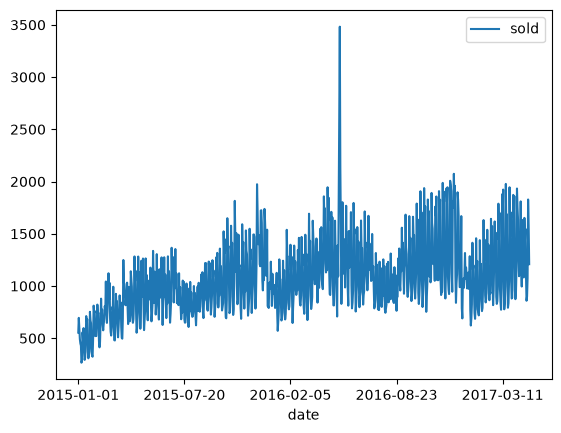

In [3]:
sales = df[['sold']]
sales.plot()

# Part #0

## Stationarity

In order to check if there's a trend or not, we need to check the series' stationarity using the Augmented Dick-Fuller's Test.

Hint: you can model a linear trend (if there's one) by adding `t` to the `regression` argument.

In [10]:
from statsmodels.tsa.stattools import adfuller

# regression='c': Specifies the model type for the test (here, 'c' includes a constant/drift term in the regression).
def adf_test(timeseries, regression='c'):
    print("Results of Dickey-Fuller Test:")
    # autolag="AIC" automatically selects the optimal lag length using Akaike Information Criterion
    dftest = adfuller(timeseries, autolag="AIC", regression=regression)
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

In [11]:
adf_test(sales.values)

Results of Dickey-Fuller Test:
Test Statistic                  -3.131253
p-value                          0.024325
#Lags Used                      21.000000
Number of Observations Used    829.000000
Critical Value (1%)             -3.438263
Critical Value (5%)             -2.865033
Critical Value (10%)            -2.568630
dtype: float64


## Is there a trend?

p-value <= 0.05: The series is stationary (no deterministic trend/unit root). You can reject the null hypothesis.

p-value >= 0.05: The series is non-stationary (it has a trend or non-constant variance/mean over time). You'll likely need to perform differencing (e.g., ts.diff()) before modeling.

## Seasonality

Now, we need to check if the series shows signs of seasonality. We may use the partial autocorrelation function (PACF) plot to investigate this.

Hint: recurring spikes as every `t` steps are a sign of a seasonality (`t` periods)

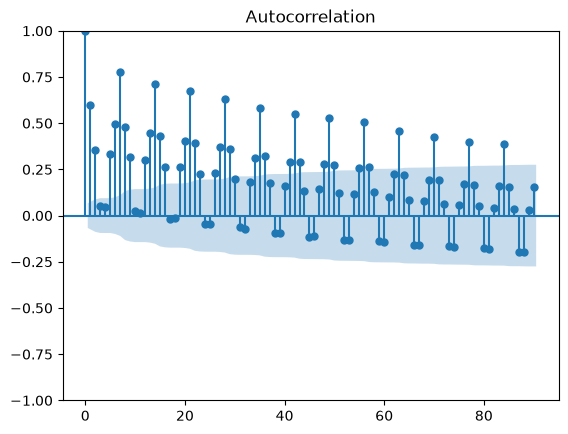

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(sales.values, lags=90);

# lags = 90 here means look at this daily data for 90 days
# If lags is set too high on a small dataset, the plot will look messy and noisy at the far right
# because the algorithm tries to compare today's sales to sales from too long ago with little overlapping data.

## The blue shade

The shaded blue area represents the threshold for statistical significance. 

The formula for that boundary narrows or widens depending on sample size and total lags displayed.

As you add more lags, distant lags naturally have less statistical power, so the threshold lines shift slightly.

## ARIMA

Let's try an ARIMA model but, first, let's save the last 28 days as our test set.

In [ ]:
from pmdarima import model_selection

train, test = model_selection.train_test_split(sales, train_size=len(sales)-28)

The ADF test implemented in `pmdarima` should give us the same result as before and, on top of that, it tell us straight away if we should differentiate the series or not.

In [ ]:
from pmdarima.arima import ADFTest

ADFTest().should_diff(train)

(0.01, False)

In order to steer the choice of the appropriate ARIMA model, we need to provide the function with the information about the need (or not) to differentiate the time series (arguments `d` and `D`, the latter for the seasonal component, if any) and if there's seasonality (`seasonal` may be true or false, and `m` specifies the number of periods in the seasonality, as you have determined above).

In [ ]:
import pmdarima as pm

d = 0
D = 0
seasonal = True
m = 7

# Fit a simple auto_arima model
arima = pm.auto_arima(train, error_action='ignore', trace=True, suppress_warnings=True, maxiter=5,
                      d=d, D=D, seasonal=seasonal, m=m)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=15706.253, Time=0.67 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=12031.986, Time=0.05 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=11373.788, Time=0.55 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=11534.052, Time=0.35 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=13896.594, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AIC=11666.611, Time=0.23 sec
 ARIMA(1,0,0)(2,0,0)[7] intercept   : AIC=13778.808, Time=1.07 sec
 ARIMA(1,0,0)(1,0,1)[7] intercept   : AIC=16844.767, Time=0.30 sec
 ARIMA(1,0,0)(0,0,1)[7] intercept   : AIC=11384.029, Time=0.35 sec
 ARIMA(1,0,0)(2,0,1)[7] intercept   : AIC=14350.617, Time=0.59 sec
 ARIMA(0,0,0)(1,0,0)[7] intercept   : AIC=11982.759, Time=0.35 sec
 ARIMA(2,0,0)(1,0,0)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(1,0,1)(1,0,0)[7] intercept   : AIC=12205.040, Time=0.29 sec
 ARIMA(0,0,1)(1,0,0)[7] intercept   : AIC=12098.087, Time=0.45 sec
 ARIMA(2,0,1)(1,0,0)[7] in

Now, let's plot the model's fitted values.

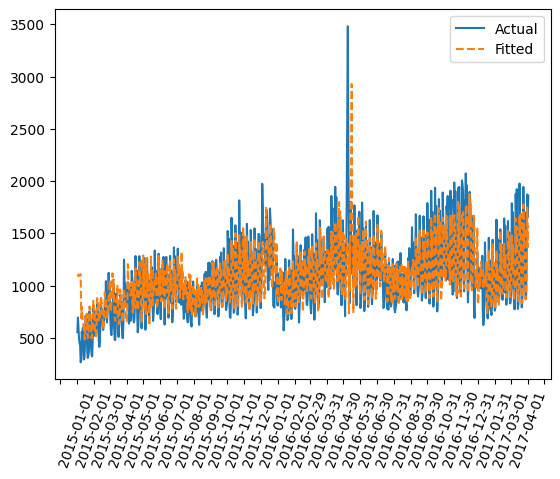

In [ ]:
fig, ax = plt.subplots(1, 1)
ax.plot(train.index, train, label='Actual')
ax.plot(train.index, arima.fittedvalues(), label='Fitted', linestyle='--')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=70)
plt.legend()

Does it look good? Do you see anything peculiar?

Then, let's try a scatter plot to compare actual and forecast values.

Text(0, 0.5, 'Forecast')

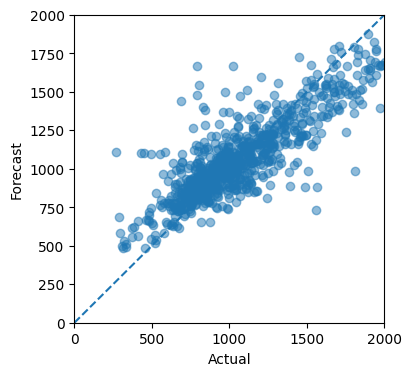

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.scatter(train, arima.fittedvalues(), alpha=0.5)
ax.plot([0, 2000], [0, 2000], linestyle='--')
ax.set_xlim([0, 2000])
ax.set_xlabel('Actual')
ax.set_ylim([0, 2000])
ax.set_ylabel('Forecast')

Does it match your expectations, after you've seen the previous plot?

Next, let's get some actual metrics for our model, namely, MAPE and sMAPE.

In [ ]:
def mape(y_true, y_pred):
    actual = y_true.copy()
    forecast = y_pred.copy()
    if isinstance(actual, (pd.Series, pd.DataFrame)):
        actual = actual.values
    if isinstance(forecast, (pd.Series, pd.DataFrame)):
        forecast = forecast.values
    if isinstance(actual, np.ndarray):
        actual = actual.squeeze()
    if isinstance(forecast, np.ndarray):
        forecast = forecast.squeeze()

    # Ensure the arrays have the same length
    assert len(actual) == len(forecast), "Length of actual and forecast arrays should be the same"

    # Avoid division by zero by replacing zeros in the 'actual' array with a small number
    actual = np.where(actual == 0, 1e-10, actual)

    # Calculate MAPE for each data point
    mape_values = np.abs((actual - forecast) / actual)

    # Calculate the mean MAPE value
    mean_mape = np.mean(mape_values) * 100  # Multiply by 100 to get percentage

    return mean_mape

def smape(y_true, y_pred):
    actual = y_true.copy()
    forecast = y_pred.copy()
    if isinstance(actual, (pd.Series, pd.DataFrame)):
        actual = actual.values
    if isinstance(forecast, (pd.Series, pd.DataFrame)):
        forecast = forecast.values
    if isinstance(actual, np.ndarray):
        actual = actual.squeeze()
    if isinstance(forecast, np.ndarray):
        forecast = forecast.squeeze()

    # Ensure the arrays have the same length
    assert len(actual) == len(forecast), "Length of actual and forecast arrays should be the same"

    # Calculate SMAPE for each data point
    smape_values = 2 * np.abs(actual - forecast) / (np.abs(actual) + np.abs(forecast))

    # Calculate the mean SMAPE value
    mean_smape = np.mean(smape_values) * 100  # Multiply by 100 to get percentage

    return mean_smape

In [ ]:
mape(train, arima.fittedvalues()),smape(train, arima.fittedvalues())

(15.465312071823636, 14.057736010075603)

Now, let's make a forecast for the 28 days in the future (our test set).

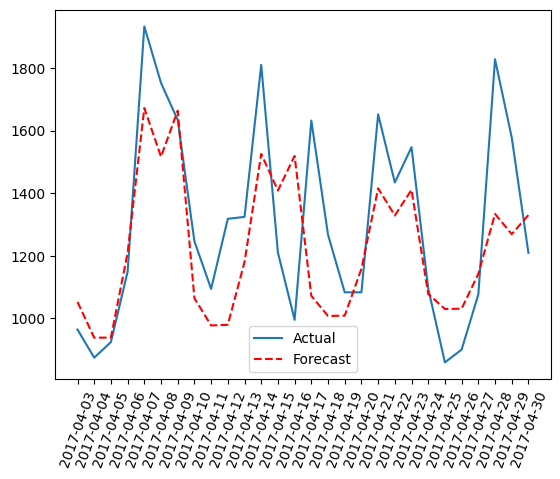

In [ ]:
x = np.arange(test.shape[0])
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, arima.predict(n_periods=len(x)), label='Forecast', linestyle='--', c='r')
plt.xticks(rotation=70)
plt.legend()

Is it good? What happens over time? Can you guess why?